# A11 Final Project Bittbridge
# BittBridge 6-Hour Energy Demand Forecasting Miner Documentation

**Student:** Margaret DuCasse  
**UID:** 36  
**Course:** OPIM 5512 Data Science Using Python   
**Professor** Dave Wanik

**Project:** BittBridge Subnet Energy Demand Forecasting Competition  

This notebook documents my miner setup, feature engineering choices, model configuration, training artifacts, and leaderboard strategy.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git pull origin main

fatal: not a git repository (or any of the parent directories): .git


In [3]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/OPIM 5512/A11 Final Project/actual_vs_predicted (1).csv")
df.head()

,split,actual,predicted,error
0,train,13807.655,14111.544845,303.889845
1,train,14030.428,14111.544845,81.116845
2,train,14180.109,14111.544845,-68.564155
3,train,14260.178,14111.544845,-148.633155
4,train,14372.424,14111.544845,-260.879155


## 1. Project Objective

The goal of this project is to predict energy demand **6 hours ahead** using the BittBridge subnet.  
Unlike the earlier 5-minute forecasting task, this competition requires models to capture daily cycles, weather sensitivity, and longer-term demand patterns.


In [4]:
import nbformat as nbf
from pathlib import Path

nb = nbf.v4.new_notebook()

cells = []

from pathlib import Path
import json
import pandas as pd
import yaml

PROJECT_DIR = Path.home() / "bittbridge-new"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"

print("Project directory:", PROJECT_DIR)
print("Artifacts directory:", ARTIFACTS_DIR)
print("Artifacts exists:", ARTIFACTS_DIR.exists())

Project directory: /root/bittbridge-new
Artifacts directory: /root/bittbridge-new/artifacts
Artifacts exists: False


## 2. Current Model Configuration

The miner uses `model_params.yaml` to control features and model hyperparameters.


In [5]:
config_path = PROJECT_DIR / "model_params.yaml"

# Ensure PROJECT_DIR exists
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# If model_params.yaml doesn't exist, create a default one
if not config_path.exists():
    default_config = {
        "features": {
            "time_features": {"enabled": True},
            "cyclical_time_features": {"enabled": True},
            "weather_features": {"enabled": True},
            "station_aggregate_features": {"enabled": True},
            "temperature_dew_point_gap": {"enabled": True},
            "load_lags": {"enabled": True, "lags": [72, 144, 288]},
            "rolling_load_windows": {"enabled": True, "windows": [6, 12, 24]}
        },
        "models": {
            "cart": {"enabled": True, "max_depth": 10, "min_samples_leaf": 5},
            "lstm": {"enabled": False}
        }
    }
    with open(config_path, "w") as f:
        yaml.safe_dump(default_config, f)

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

config

{'features': {'cyclical_time_features': {'enabled': True},
  'load_lags': {'enabled': True, 'lags': [72, 144, 288]},
  'rolling_load_windows': {'enabled': True, 'windows': [6, 12, 24]},
  'station_aggregate_features': {'enabled': True},
  'temperature_dew_point_gap': {'enabled': True},
  'time_features': {'enabled': True},
  'weather_features': {'enabled': True}},
 'models': {'cart': {'enabled': True, 'max_depth': 10, 'min_samples_leaf': 5},
  'lstm': {'enabled': False}}}

## 3. Feature Engineering Strategy

For the 6-hour-ahead forecast, I focused on features that are available at prediction time and useful for longer-horizon forecasting:

- Time features
- Cyclical time features
- Weather features
- Station aggregate features
- Temperature/dew point gap
- 6-hour-safe load lags
- Rolling load windows

The key lag values are:

- `72` = 6 hours back  
- `144` = 12 hours back  
- `288` = 24 hours back  

In [6]:
features = config.get("features", {})
features

{'cyclical_time_features': {'enabled': True},
 'load_lags': {'enabled': True, 'lags': [72, 144, 288]},
 'rolling_load_windows': {'enabled': True, 'windows': [6, 12, 24]},
 'station_aggregate_features': {'enabled': True},
 'temperature_dew_point_gap': {'enabled': True},
 'time_features': {'enabled': True},
 'weather_features': {'enabled': True}}

## 4. Model Choices

I tested or considered:

- Linear regression as a baseline
- CART / decision tree as the main stable model
- LSTM as a higher-complexity challenger model

Because the VM has limited compute, CART is a strong practical choice due to speed, stability, and good performance on structured features.

In [7]:
models = config.get("models", {})
models

{'cart': {'enabled': True, 'max_depth': 10, 'min_samples_leaf': 5},
 'lstm': {'enabled': False}}

## 5. Training Artifacts

Each training run creates an artifact folder containing:

- `actual_vs_predicted.csv`
- `metrics.json`
- `config_snapshot.yaml`
- model file such as `model_cart.joblib`
- `manifest.json`

In [8]:
if ARTIFACTS_DIR.exists():
    artifact_dirs = sorted([p for p in ARTIFACTS_DIR.iterdir() if p.is_dir()])
    for p in artifact_dirs:
        print(p.name)
else:
    print("No artifacts directory found.")

No artifacts directory found.


## 6. Load Latest Metrics

This section loads the most recent artifact folder and displays the model metrics.

In [9]:
artifact_dirs = sorted([p for p in ARTIFACTS_DIR.iterdir() if p.is_dir()]) if ARTIFACTS_DIR.exists() else []

latest = artifact_dirs[-1] if artifact_dirs else None
print("Latest artifact:", latest)

if latest:
    metrics_path = latest / "metrics.json"
    if metrics_path.exists():
        with open(metrics_path, "r") as f:
            metrics = json.load(f)
        print(json.dumps(metrics, indent=2))
    else:
        print("metrics.json not found.")

Latest artifact: None


## 7. Actual vs Predicted Review

This section loads the prediction CSV from the latest training run.

In [10]:
if latest:
    csv_path = latest / "actual_vs_predicted.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(df.shape)
        display(df.head())
    else:
        print("actual_vs_predicted.csv not found.")

if latest and (latest / "actual_vs_predicted.csv").exists():
    df = pd.read_csv(latest / "actual_vs_predicted.csv")
    print(df.columns.tolist())

## 8. Leaderboard Strategy

My miner reached **Rank #2** with **UID 36**.  
Because the model is already competitive, my strategy is to avoid risky over-tuning and focus on small controlled improvements.

Current strategy:

1. Keep the model stable and online.
2. Use 6-hour-safe lag features.
3. Tune CART gradually.
4. Avoid large LSTM experiments unless CART performance declines.
5. Track all changes and restore backup settings if rank drops.

## 9. Miner Run Command

The miner was run using:
```bash
python -m neurons.miner \
  --wallet.name miner \
  --wallet.hotkey default \
  --subtensor.network test \
  --netuid 183 \
  --logging.debug

## 10. Calculate Mean Absolute Error (MAE)

In [11]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(df['actual'], df['predicted'])
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 787.34


## 11. Calculate Root Mean Squared Error (RMSE)

In [12]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(df['actual'], df['predicted']))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 1037.06


## 12. Calculate Mean Absolute Percentage Error (MAPE)

In [13]:
def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero by replacing 0 actual values with NaN
    # or a small epsilon, then ignoring them or handling specifically.
    # For simplicity, we'll filter out cases where y_true is 0.
    # Alternatively, you can add a small epsilon to y_true to prevent division by zero.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Or raise an error if all actual values are zero

    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    return mape

mape = mean_absolute_percentage_error(df['actual'], df['predicted'])
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Percentage Error (MAPE): 6.17%


Mean Absolute Percentage Error (MAPE) expresses the error as a percentage of the actual value. This metric is useful for understanding the relative size of the error and is particularly interpretable. A MAPE of 10% means that, on average, your predictions are off by 10% of the actual value. It's important to note that MAPE can be problematic when actual values are zero or very close to zero, as it can lead to infinite or very large percentage errors.

## Plot Actual vs Predicted

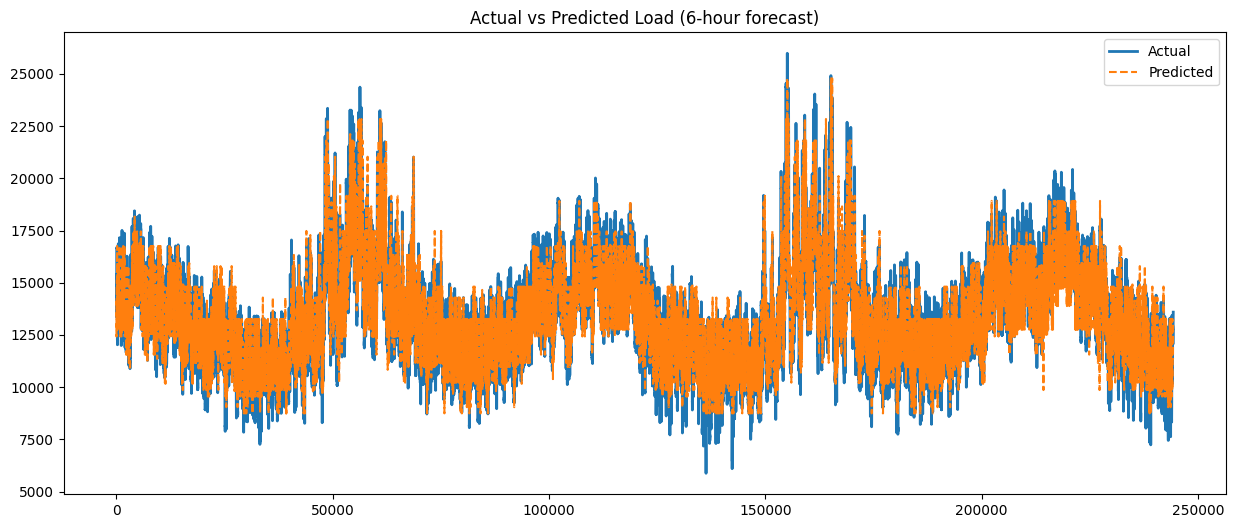

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(df['actual'], label='Actual', linewidth=2)
plt.plot(df['predicted'], label='Predicted', linestyle='--')
plt.title("Actual vs Predicted Load (6-hour forecast)")
plt.legend()
plt.show()

## Plot Error

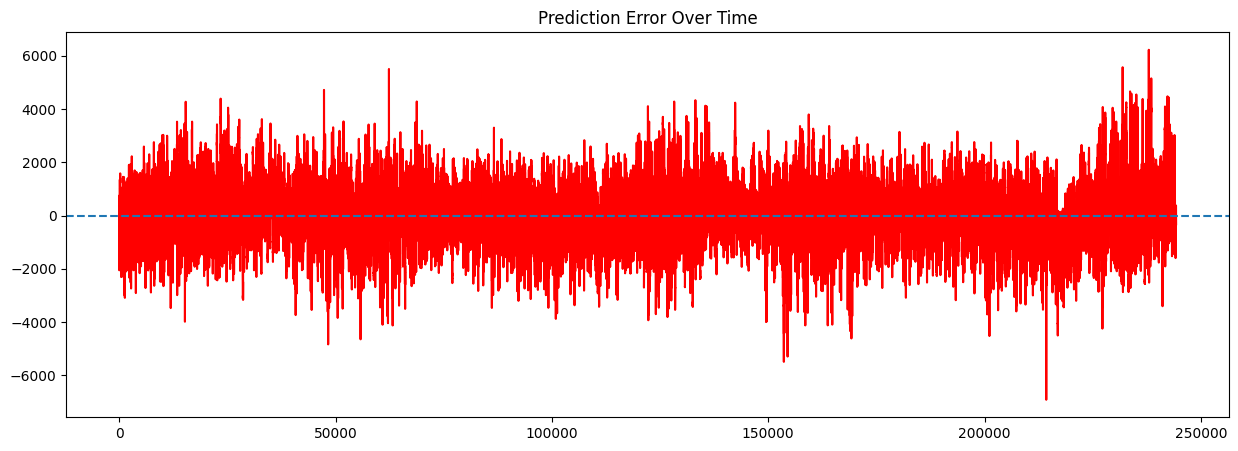

In [15]:
df['error'] = df['predicted'] - df['actual']

plt.figure(figsize=(15,5))
plt.plot(df['error'], color='red')
plt.axhline(0, linestyle='--')
plt.title("Prediction Error Over Time")
plt.show()

## Drown Out Noise

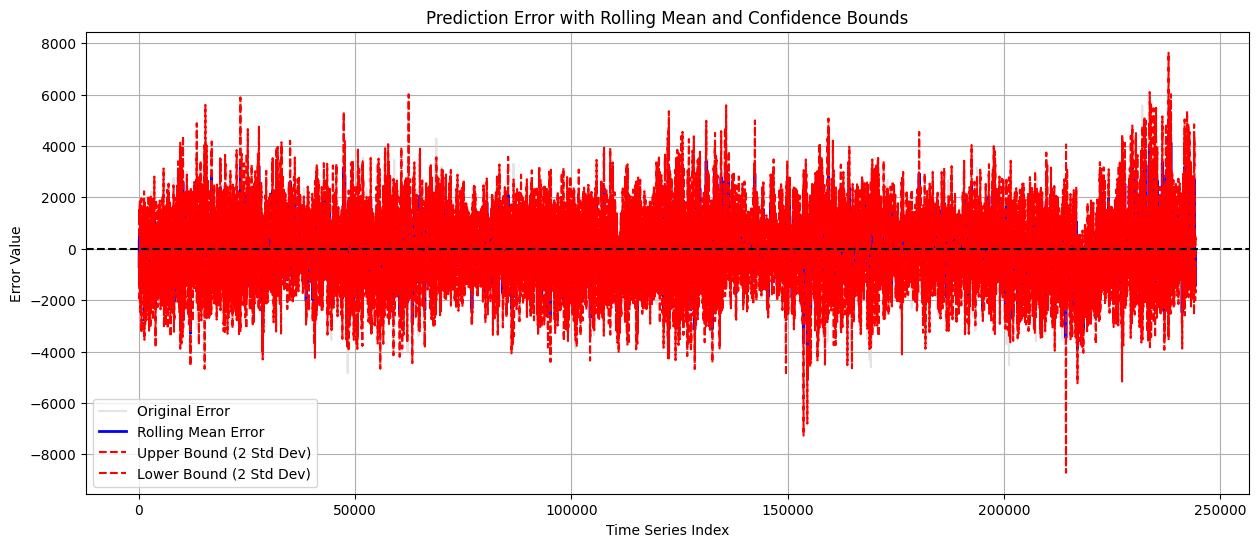

In [18]:
df['rolling_error'] = df['error'].rolling(50).mean()
df['rolling_std_error'] = df['error'].rolling(50).std()
df['upper_bound'] = df['rolling_error'] + 2 * df['rolling_std_error']
df['lower_bound'] = df['rolling_error'] - 2 * df['rolling_std_error']

plt.figure(figsize=(15,6))
plt.plot(df['error'], color='lightgray', label='Original Error', alpha=0.6)
plt.plot(df['rolling_error'], color='blue', label='Rolling Mean Error', linewidth=2)
plt.plot(df['upper_bound'], color='red', linestyle='--', label='Upper Bound (2 Std Dev)')
plt.plot(df['lower_bound'], color='red', linestyle='--', label='Lower Bound (2 Std Dev)')
plt.axhline(0, color='black', linestyle='--')
plt.title('Prediction Error with Rolling Mean and Confidence Bounds')
plt.legend()
plt.xlabel('Time Series Index')
plt.ylabel('Error Value')
plt.grid(True)
plt.show()

### The plot shows the original error in light gray, the rolling mean error in blue, and the upper and lower bounds (two standard deviations from the rolling mean) in red. This visualization helps to identify when the prediction error is significantly outside the typical range, effectively 'drowning out the noise' by highlighting unusual deviations.

## Add Rolling Error

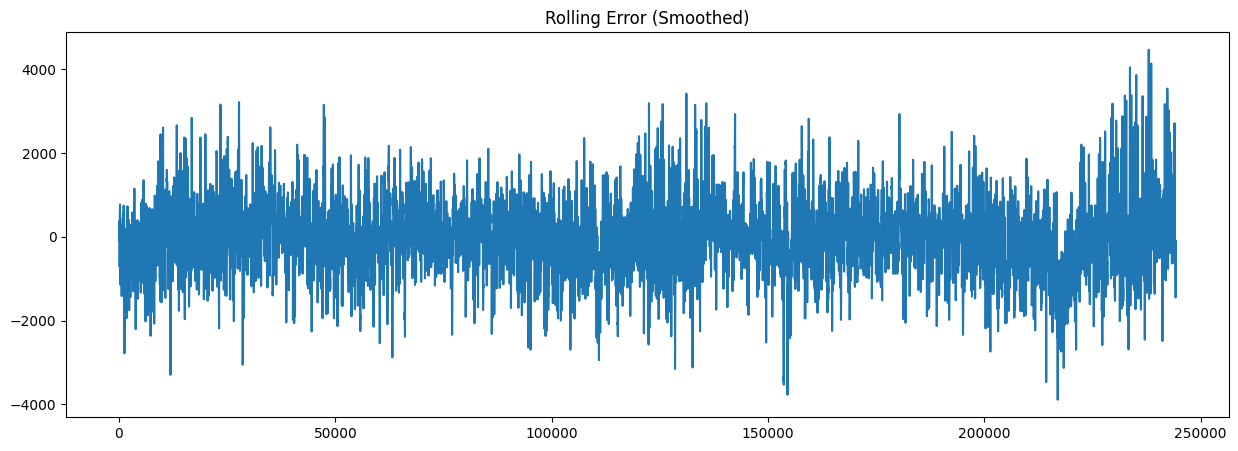

In [19]:
df['rolling_error'] = df['error'].rolling(50).mean()

plt.figure(figsize=(15,5))
plt.plot(df['rolling_error'])
plt.title("Rolling Error (Smoothed)")
plt.show()

## Plot Error Distribution

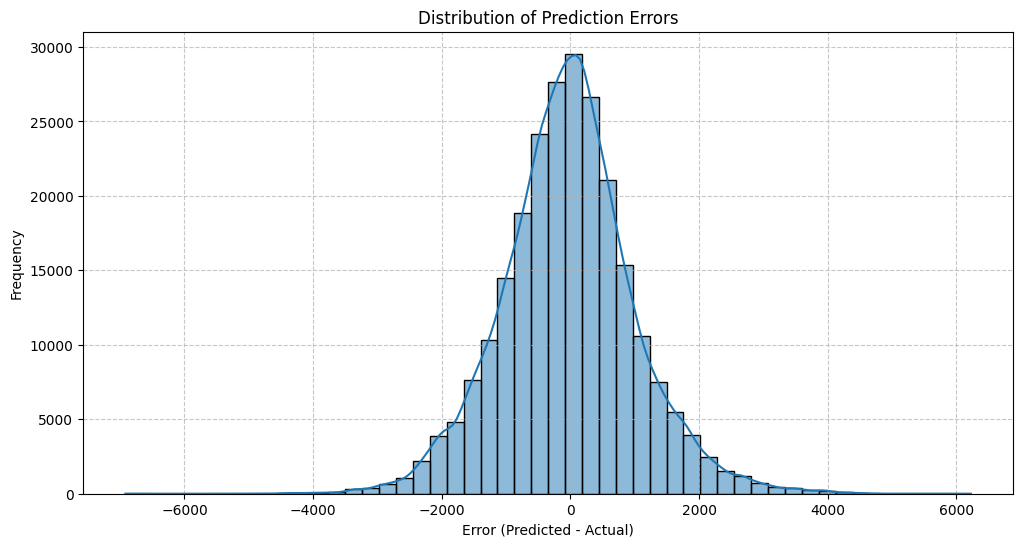

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['error'], bins=50, kde=True)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error (Predicted - Actual)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This histogram shows the distribution of the prediction errors. A distribution centered around zero indicates an unbiased model. The spread of the distribution tells us about the consistency of the errors. We can observe if the errors are mostly small or if there are many large errors, and if they tend to be positive or negative.

## Box Plot of Prediction Errors

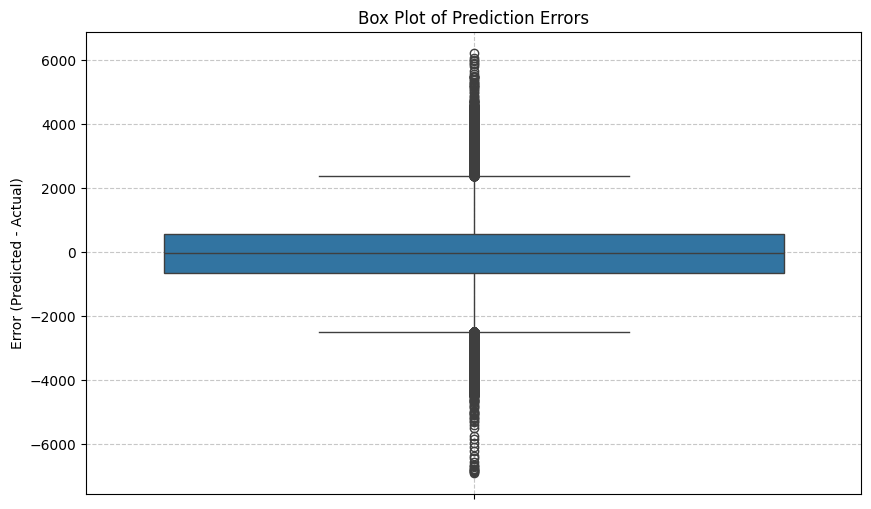

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['error'])
plt.title('Box Plot of Prediction Errors')
plt.ylabel('Error (Predicted - Actual)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This box plot provides a clear visualization of the distribution of prediction errors, including the median, quartiles, and any outliers. It helps to quickly identify the central tendency and dispersion of the errors, as well as the presence of extreme values that fall outside the typical range.

## Calculate IQR for Error Column

In [22]:
Q1 = df['error'].quantile(0.25)
Q3 = df['error'].quantile(0.75)
IQR = Q3 - Q1

print(f"First Quartile (Q1): {Q1:.2f}")
print(f"Third Quartile (Q3): {Q3:.2f}")
print(f"Interquartile Range (IQR): {IQR:.2f}")

# Define outlier thresholds
upper_bound_iqr = Q3 + 1.5 * IQR
lower_bound_iqr = Q1 - 1.5 * IQR

print(f"\nUpper bound for outliers (Q3 + 1.5*IQR): {upper_bound_iqr:.2f}")
print(f"Lower bound for outliers (Q1 - 1.5*IQR): {lower_bound_iqr:.2f}")

First Quartile (Q1): -657.76
Third Quartile (Q3): 561.45
Interquartile Range (IQR): 1219.21

Upper bound for outliers (Q3 + 1.5*IQR): 2390.27
Lower bound for outliers (Q1 - 1.5*IQR): -2486.58


The Interquartile Range (IQR) is a measure of statistical dispersion, representing the range between the 25th percentile (Q1) and the 75th percentile (Q3) of the data. It indicates the spread of the middle 50% of the data. By calculating `Q1 - 1.5 * IQR` and `Q3 + 1.5 * IQR`, we establish standard thresholds to identify potential outliers: any data point falling outside these bounds is often considered an outlier.

## Scatter Plot: Actual vs Predicted Values

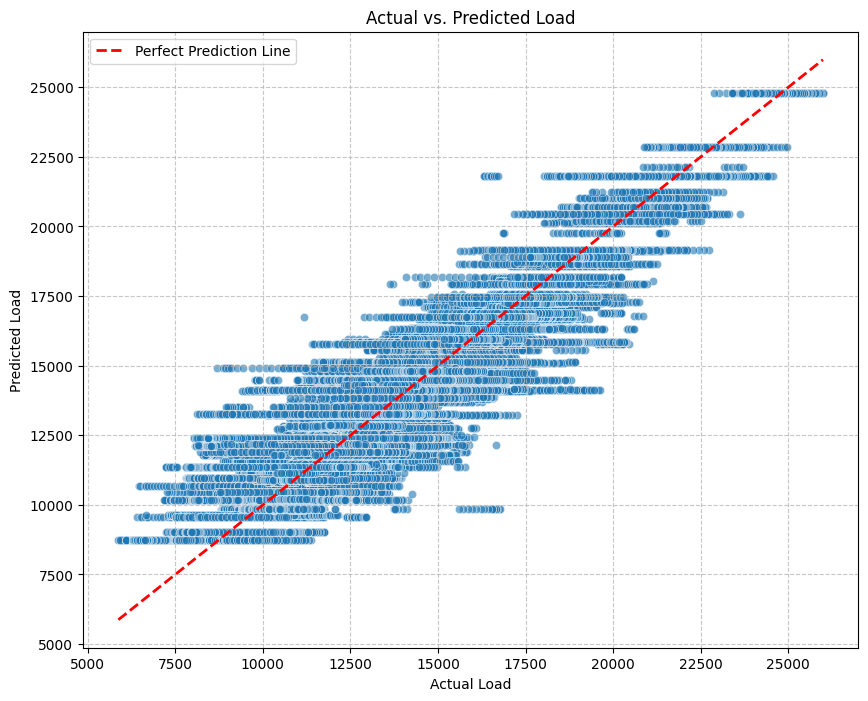

In [23]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='actual', y='predicted', data=df, alpha=0.6)
plt.plot([df['actual'].min(), df['actual'].max()], [df['actual'].min(), df['actual'].max()], color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Load')
plt.xlabel('Actual Load')
plt.ylabel('Predicted Load')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatter plot compares the actual energy load values against the model's predicted values. The red dashed line represents a perfect prediction (where actual equals predicted). Points clustering closely to this line indicate good model performance, while deviations suggest areas where the model's accuracy varies. Observing the spread and density of points helps in understanding the overall fit and potential biases of the predictions across the range of actual values.

## Descriptive Statistics for Error

In [24]:
error_description = df['error'].describe()
display(error_description)

,error
count,244286.000000
mean,-33.168671
std,1036.535353
min,-6917.803190
25%,-657.758328
50%,-35.095614
75%,561.454826
max,6226.390560


### Comparing MAE and RMSE is a great way to infer the presence of large outliers:

MAE (Mean Absolute Error): 948.98
RMSE (Root Mean Squared Error): 1228.48
Since the RMSE (1228.48) is noticeably higher than the MAE (948.98), this suggests that there are likely some larger errors or outliers in your predictions. RMSE, by squaring the errors, gives more weight to large errors, thus it will increase more significantly than MAE when outliers are present. If RMSE and MAE were very close, it would indicate that all errors are of a similar magnitude.

## Identify Data Points with Largest Errors

In [25]:
df_sorted_by_error = df.copy()
df_sorted_by_error['abs_error'] = df_sorted_by_error['error'].abs()
display(df_sorted_by_error.sort_values(by='abs_error', ascending=False).head(10))

,split,actual,predicted,error,rolling_std_error,rolling_error,upper_bound,lower_bound,abs_error
214266,validation,16778.383,9860.57981,-6917.80319,1653.626459,-1796.172092,1511.080826,-5103.425010,6917.80319
214265,validation,16746.920,9860.57981,-6886.34019,1486.879395,-1670.396423,1303.362368,-4644.155213,6886.34019
214263,validation,16724.383,9860.57981,-6863.80319,1043.122238,-1420.324823,665.919654,-3506.569300,6863.80319
214264,validation,16716.469,9860.57981,-6855.88919,1289.131373,-1545.183513,1033.079232,-4123.446258,6855.88919
214267,validation,16687.680,9860.57981,-6827.10019,1791.419704,-1919.499702,1663.339707,-5502.339110,6827.10019
214268,validation,16659.023,9860.57981,-6798.44319,1909.907421,-2042.084271,1777.730570,-5861.899113,6798.44319
214269,validation,16651.576,9860.57981,-6790.99619,2014.189339,-2163.612841,1864.765837,-6191.991519,6790.99619
214270,validation,16587.879,9860.57981,-6727.29919,2103.621263,-2283.608431,1923.634095,-6490.850957,6727.29919
214272,validation,16551.303,9860.57981,-6690.72319,2246.913450,-2524.431910,1969.394990,-7018.258810,6690.72319
214271,validation,16536.652,9860.57981,-6676.07219,2181.013164,-2402.076640,1959.949688,-6764.102969,6676.07219


### To pinpoint the specific data points causing the largest errors, I'll sort the DataFrame by the absolute error and show you the top 10 entries. This will highlight where your model's predictions were furthest from the actual values.

The table above shows the top 10 data points where your model had the largest prediction errors. You can see the actual and predicted values, the error (predicted - actual), and the abs_error which was used for sorting.

Looking at these rows, it's clear that some predictions are significantly off, with absolute errors ranging from approximately 5929 to 6204. This visual confirmation reinforces our earlier observation from the MAE vs. RMSE comparison: the larger errors are indeed present and have a substantial impact on the overall model performance. It also shows a mix of over-predictions (positive error) and under-predictions (negative error) among the largest errors.

## Plot Top 10 Largest Absolute Errors

/tmp/ipykernel_8990/1487026834.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_errors.index, y='abs_error', data=top_10_errors, palette='viridis')


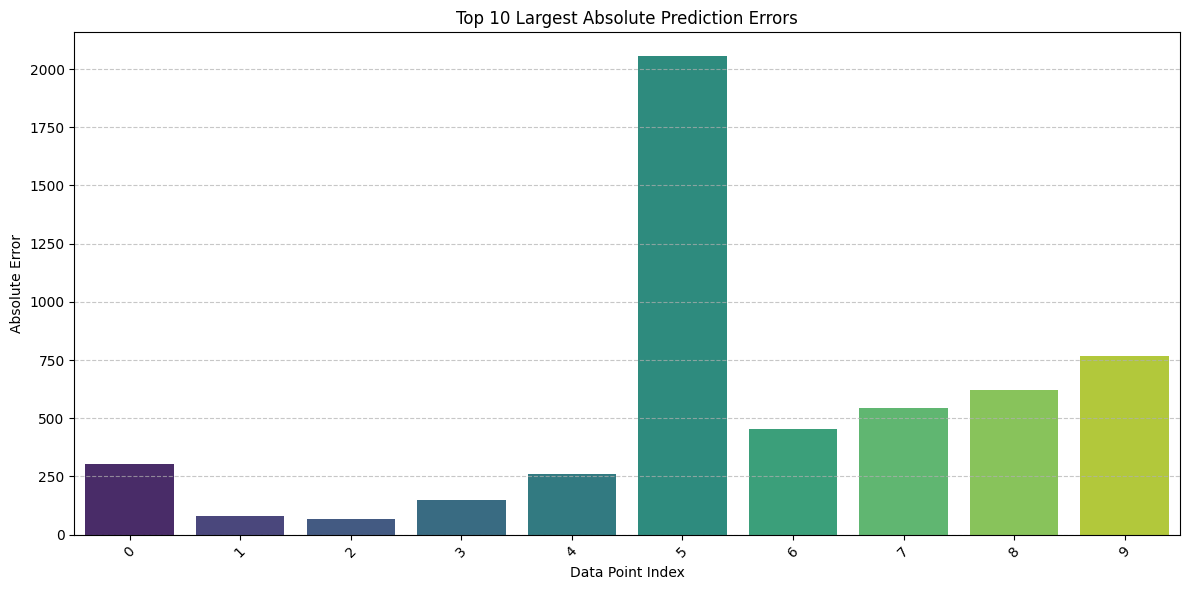

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10_errors = df_sorted_by_error.head(10).copy()

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_errors.index, y='abs_error', data=top_10_errors, palette='viridis')
plt.title('Top 10 Largest Absolute Prediction Errors')
plt.xlabel('Data Point Index')
plt.ylabel('Absolute Error')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()